In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [2]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 2
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [3]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)
bases = [basis]*d_lift

In [ ]:
from ctt.tt import tt_randn

key, *control_keys = random.split(key, 2+1)

target_ranks = [d_lift] + [2]*(d_lift-1) + [1]
target_tts = [
    tt_randn(control_key, [n_features] * d_lift, target_ranks, cov=3.0)
    for control_key in control_keys
]
target_ctt = make_ctt(lift, retraction, basis, d)

Sigma = random.normal(key=key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "bivariate"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "recovery":
        val = target_ctt(target_tts, x)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.mean((x[::2] + x[1::2]) ** 2)
    return jnp.atleast_1d(val)



In [15]:
from ctt.tt import validate_ranks

key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 1_000_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2
regularization_coeff = 0.
radius = None
rank = 2
ranks = [d_lift] + [rank]*(d_lift-1) + [1]
ranks = validate_ranks([n_features]*d_lift, ranks)

In [16]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [17]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"]) -> float:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    return 0.5*loss

@jax.jit
def grad_loss(y_hat: Float[Array, "B d_o"], y: Float[Array, "B d_o"]) -> Float[Array, "B d_o"]:
    # return y_hat - y
    return (y_hat - y) / y_hat.shape[0]

In [18]:
from ctt.tt import tt_orthogonalize

def left_orth(tt: TT) -> TT:
    U, V, S = tt_orthogonalize(tt)
    return [S[0]] + V

# Natural gradient descent

In [19]:
from functools import partial
from ctt.ngd import ctt_natural_grad, ctt_apply_updates, ctt_linesearch
from ctt.tt import tt_mul_scalar

def ngd(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
        params: list[TT],
        opt_steps: int,
        training_key: PRNGKeyArray,
        batch_size: int = 64) -> tuple[list[TT], tuple[list[float], list[float]], list[float]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    train_losses = []
    val_losses = []
    learning_rates = []

    ls_init_fn, ls_update_fn = ctt_linesearch(max_backtracking_steps=20,
                                              condition="armijo",
                                              increase_factor=1.,
                                              decrease_factor=0.8,
                                              atol=0.)
    state = ls_init_fn(params)

    compute_natural_grads, compute_grads = ctt_natural_grad(bases,
                                                            lift,
                                                            retraction,
                                                            grad_loss)

    @jax.jit
    def step(tts: list[TT],
             x: Float[Array, "B d"],
             y: Float[Array, "B d_o"],
             state):
        # it should not be the gradient given by the autodiff, but rather the functional gradient
        loss = compute_loss(tts, x, y)
        natural_grads = compute_natural_grads(tts, x, y=y)
        updates = list(map(partial(tt_mul_scalar, val=-1.), natural_grads))

        def _grad(params: list[TT], y: Float[Array, "B d_o"]) -> list[TT]:
            grads = compute_grads(params, x, y=y)
            # contract the first two cores
            grads = [
                [jnp.einsum("ijk,kmn->jmn", tt[0], tt[1])] + tt[2:]
                for tt in grads
            ]
            return grads

        updates, state = ls_update_fn(updates, state, tts,
                                      value=loss,
                                      grad=_grad(tts, y=y),
                                      value_fn=partial(compute_loss, x=x),
                                      grad_fn=_grad,
                                      y=y)

        params = ctt_apply_updates(tts, updates)
        # params = list(map(left_orth, params))
        return state, params, loss
    
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        state, params, loss = step(params, x, y, state)
        learning_rates.append(state.learning_rate)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(loss)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {loss:.3e} | Val loss: {val_loss:.3e} | Decrease: {loss-state.value:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [20]:
from ctt.tt import tt_zeros, tt_randn

key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    tt_randn(control_key, [n_features] * d_lift, ranks, cov=1.)
    for control_key in control_keys
]
init_controls = list(map(left_orth, (init_controls)))
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
# init_controls = list(map(left_orth, init_controls))
print(list(map(tt_norm, init_controls)))

[Array(0.11083701, dtype=float64), Array(0.14273002, dtype=float64)]


In [21]:
params, (train_losses, val_losses), learning_rates = ngd(train_dataset=(X_train, y_train),
                                         val_dataset=(X_val, y_val),
                                         params=init_controls,
                                         opt_steps=40_000,
                                         training_key=training_key,
                                         batch_size=64)

Iter 0 | Loss: 7.651e-02 | Val loss: 7.898e-02 | Decrease: 4.736e-03
Iter 5 | Loss: 6.237e-02 | Val loss: 5.744e-02 | Decrease: 3.844e-03
Iter 10 | Loss: 4.177e-02 | Val loss: 4.177e-02 | Decrease: 2.576e-03
Iter 15 | Loss: 2.880e-02 | Val loss: 3.036e-02 | Decrease: 1.781e-03
Iter 20 | Loss: 2.213e-02 | Val loss: 2.200e-02 | Decrease: 1.382e-03
Iter 25 | Loss: 1.788e-02 | Val loss: 1.597e-02 | Decrease: 1.108e-03
Iter 30 | Loss: 1.105e-02 | Val loss: 1.160e-02 | Decrease: 6.824e-04
Iter 35 | Loss: 7.548e-03 | Val loss: 8.438e-03 | Decrease: 4.657e-04
Iter 40 | Loss: 5.906e-03 | Val loss: 6.137e-03 | Decrease: 3.642e-04
Iter 45 | Loss: 4.307e-03 | Val loss: 4.465e-03 | Decrease: 2.655e-04
Iter 50 | Loss: 3.606e-03 | Val loss: 3.248e-03 | Decrease: 2.222e-04
Iter 55 | Loss: 2.071e-03 | Val loss: 2.364e-03 | Decrease: 1.276e-04
Iter 60 | Loss: 2.079e-03 | Val loss: 1.720e-03 | Decrease: 1.280e-04
Iter 65 | Loss: 1.412e-03 | Val loss: 1.252e-03 | Decrease: 8.695e-05
Iter 70 | Loss: 8.948e

Text(0, 0.5, 'Learning rate')

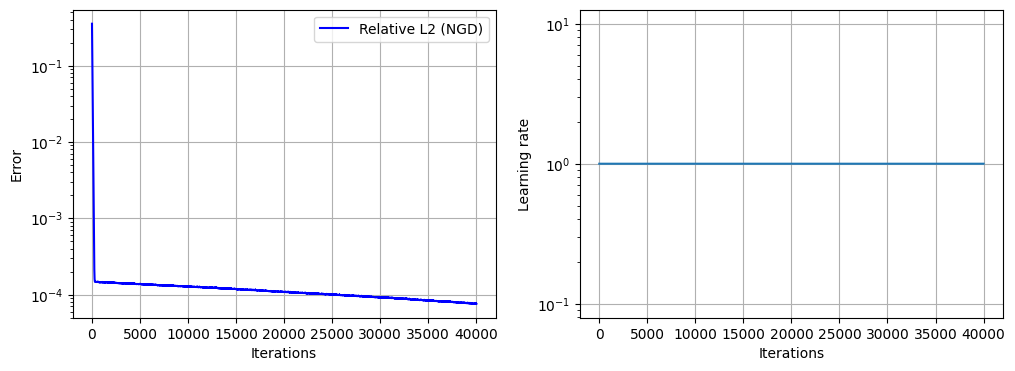

In [22]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses = jnp.asarray(val_losses)

axes[0].semilogy(jnp.arange(len(val_losses)), jnp.sqrt(val_losses/y_val_norm), label="Relative L2 (NGD)", color="blue")

axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Error")

# plot learning rates
axes[1].semilogy(learning_rates)
axes[1].grid()
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Learning rate")